# 06 — Real-Time API, Stream Simulation & Concept Drift

This notebook has three parts:

1. **API walkthrough** — explain `src/api.py` and test its prediction logic directly.
2. **Live stream simulation** — replay CMAPSS test sequences cycle-by-cycle and watch the model issue HIGH RISK alerts as engines approach failure.
3. **Concept drift detection** — use Evidently AI to flag when a sensor's statistical distribution shifts, signalling that the model may no longer be trustworthy.

**Why this matters:**  
Notebooks 3–5 proved the model works on static data. This notebook answers the harder question: *what happens when the model runs continuously on a live feed?* That is what separates a research prototype from an operational system.

## Part 1 — API Architecture Walkthrough

The API lives in `src/api.py` and is built with **FastAPI** — a modern Python web framework that validates inputs automatically, generates interactive docs, and handles concurrent requests.

### What happens on every `POST /predict` call

```
Client sends:
  engine_id       — which engine this reading is from
  feature_vector  — 110 precomputed features (raw + rolling stats)
  sensor_window   — 30×11 raw sensor window for the autoencoder

API returns:
  rul_estimate    — predicted cycles until failure (XGBoost)
  risk_level      — "SAFE" or "HIGH RISK" (RUL < 30)
  anomaly_score   — autoencoder reconstruction MAE
  anomaly_flag    — True if score exceeds learned threshold
  top_features    — top 5 SHAP drivers for this specific prediction
```

Both models run on every call so the operator gets two independent signals — the regression-based RUL number and the unsupervised anomaly flag — which reinforce each other when they agree.

### To run the live API server
```bash
# From the project root
uvicorn src.api:app --reload --host 0.0.0.0 --port 8000
# Then open: http://localhost:8000/docs
```

### Step 1.1 — Load all artifacts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os

import shap
from evidently import Report
from evidently.presets import DataDriftPreset

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../results', exist_ok=True)

with open('../results/anomaly_threshold.txt') as f:
    AE_THRESHOLD = float(f.read())
with open('../data/processed/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

X_feat  = np.load('../data/processed/X_features.npy')
y_rul   = np.load('../data/processed/y_rul.npy')
eng_ids = np.load('../data/processed/engine_ids_flat.npy')

ALERT_RUL = 30
print(f"AE threshold: {AE_THRESHOLD:.4f}  |  Features: {len(FEATURE_COLS)}")

/Users/vladabalinsky/Desktop/Anomaly/venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AE threshold: 0.0937  |  Features: 110


### Step 1.2 — Batch-compute all predictions upfront

Rather than calling each model one sample at a time (which would be slow for 17K windows), we run everything in a single batch pass — the same way a production system would process a queue of incoming readings. SHAP values, autoencoder scores, and XGBoost RUL predictions are all computed here once, then the stream simulation below simply replays these stored results.

In [2]:
# Load pre-computed results (generated once by src/precompute.py).
# This avoids re-running TF + SHAP on every notebook open — those are slow
# on CPU and are better run as a one-off offline job.

rul_pred     = np.load('../data/processed/precomp_rul_pred.npy')
ae_score     = np.load('../data/processed/precomp_ae_score.npy')
shap_vals    = np.load('../data/processed/precomp_shap_vals.npy')
shap_idx     = np.load('../data/processed/precomp_shap_idx.npy')
shap_single  = np.load('../data/processed/precomp_shap_single.npy')
last_i       = int(np.load('../data/processed/precomp_last_i.npy')[0])
eng_ids_test = np.load('../data/processed/precomp_eng_ids_test.npy')
y_rul_test   = np.load('../data/processed/precomp_y_rul_test.npy')

with open('../data/processed/precomp_expected_value.pkl', 'rb') as f:
    expected_value = pickle.load(f)

X_feat_test = X_feat[np.isin(eng_ids, np.unique(eng_ids)[80:])]

all_rul_pred = rul_pred
all_risk     = np.where(all_rul_pred < ALERT_RUL, 'HIGH RISK', 'SAFE')
all_ae_score = ae_score
all_ae_flag  = ae_score > AE_THRESHOLD

print(f"Precomputed results loaded.")
print(f"  RUL predictions: {all_rul_pred.shape}")
print(f"  AE scores:       {all_ae_score.shape}")
print(f"  SHAP values:     {shap_vals.shape}  (200-sample subset)")

Precomputed results loaded.
  RUL predictions: (3913,)
  AE scores:       (3913,)
  SHAP values:     (200, 110)  (200-sample subset)


### Step 1.3 — Single prediction demo

We look up the precomputed results for one specific window — engine 85 at its last cycle, closest to failure — and format the output exactly as the API would return it to a client.

In [3]:
rul_est  = all_rul_pred[last_i]
risk     = all_risk[last_i]
ae_s     = all_ae_score[last_i]
ae_flag  = bool(all_ae_flag[last_i])
top_idx  = np.argsort(np.abs(shap_single))[::-1][:5]

print("POST /predict  ->  Response:")
print(f"  engine_id:     engine_85")
print(f"  rul_estimate:  {rul_est:.1f} cycles")
print(f"  risk_level:    {risk}")
print(f"  anomaly_score: {ae_s:.4f}  (threshold {AE_THRESHOLD:.4f})")
print(f"  anomaly_flag:  {ae_flag}")
print()
print("  top_features:")
for i in top_idx:
    direction = "pushes RUL up" if shap_single[i] > 0 else "pushes RUL DOWN (toward failure)"
    print(f"    {FEATURE_COLS[i]:<32}  {shap_single[i]:+.3f}   {direction}")

POST /predict  ->  Response:
  engine_id:     engine_85
  rul_estimate:  3.7 cycles
  risk_level:    HIGH RISK
  anomaly_score: 0.1139  (threshold 0.0937)
  anomaly_flag:  True

  top_features:
    sensor_12_mean10                  -22.899   pushes RUL DOWN (toward failure)
    sensor_11_mean10                  -16.559   pushes RUL DOWN (toward failure)
    sensor_7_mean10                   -11.961   pushes RUL DOWN (toward failure)
    sensor_21_mean10                  -6.501   pushes RUL DOWN (toward failure)
    sensor_12_mean5                   -4.315   pushes RUL DOWN (toward failure)


### Step 1.4 — SHAP waterfall for this window

The waterfall plot shows exactly why the model predicted this RUL. Each bar is one feature's contribution — red bars push the prediction lower (fewer cycles remaining), blue bars push it higher. This is what you would show an operator who asks: *"Why is Engine 85 flagged as HIGH RISK?"*

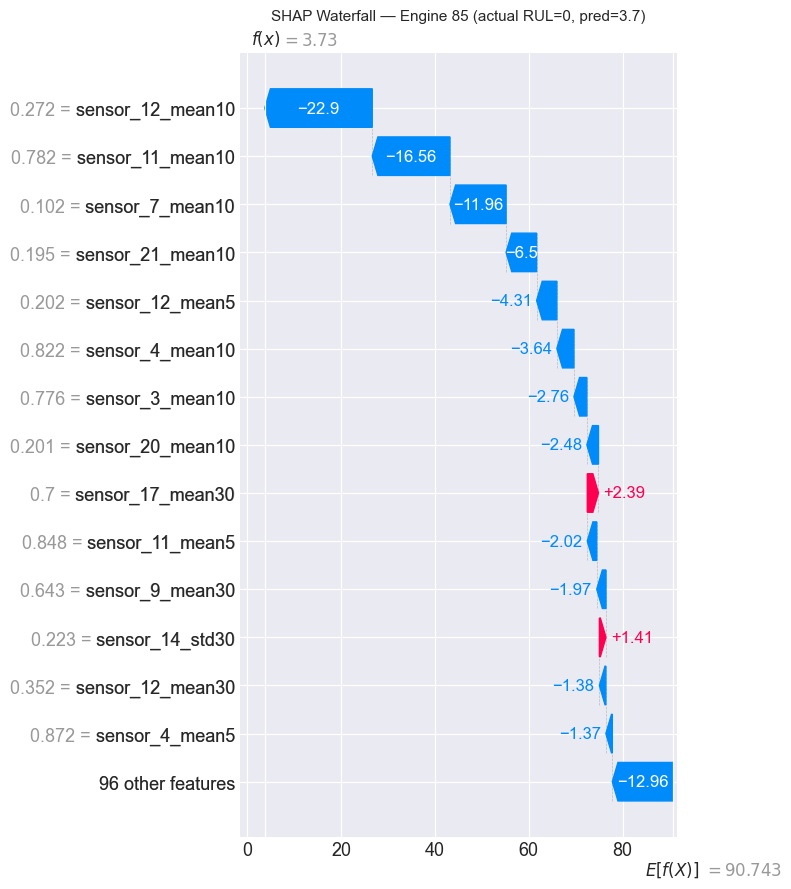

In [4]:
shap_exp = shap.Explanation(
    values        = shap_single,
    base_values   = expected_value,
    data          = X_feat_test[last_i],
    feature_names = FEATURE_COLS
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Engine 85 (actual RUL={y_rul_test[last_i]:.0f}, pred={all_rul_pred[last_i]:.1f})', fontsize=11)
plt.tight_layout()
plt.savefig('../results/api_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2 — Live Stream Simulation

We replay CMAPSS test sequences window-by-window for 6 engines, exactly as a real-time sensor feed would arrive. The model issues a HIGH RISK alert the first time its predicted RUL drops below 30 cycles. We record how much actual life remained at that moment — that is the **warning lead time** the system gives before failure.

The purple dots mark windows where the LSTM autoencoder independently flagged an anomaly. When both the XGBoost alert and the autoencoder flag agree, the operator has a much stronger signal.

In [5]:
def simulate_engine(engine_id):
    mask    = eng_ids_test == engine_id
    indices = np.where(mask)[0]
    return pd.DataFrame({
        'actual_rul':    y_rul_test[indices],
        'pred_rul':      all_rul_pred[indices],
        'risk_level':    all_risk[indices],
        'anomaly_score': all_ae_score[indices],
        'anomaly_flag':  all_ae_flag[indices],
    })

sim_engines = [81, 82, 83, 84, 85, 86]
sim_results = {eng: simulate_engine(eng) for eng in sim_engines}

for eng, df in sim_results.items():
    alert_rows = np.where(df['risk_level'] == 'HIGH RISK')[0]
    far = f"{df['actual_rul'].iloc[alert_rows[0]]:.0f} cycles" if len(alert_rows) else 'no alert'
    print(f"Engine {eng}: {len(df)} windows | first HIGH RISK alert at RUL = {far}")

Engine 81: 211 windows | first HIGH RISK alert at RUL = 41 cycles
Engine 82: 185 windows | first HIGH RISK alert at RUL = 27 cycles
Engine 83: 264 windows | first HIGH RISK alert at RUL = 42 cycles
Engine 84: 238 windows | first HIGH RISK alert at RUL = 36 cycles
Engine 85: 159 windows | first HIGH RISK alert at RUL = 25 cycles
Engine 86: 249 windows | first HIGH RISK alert at RUL = 42 cycles


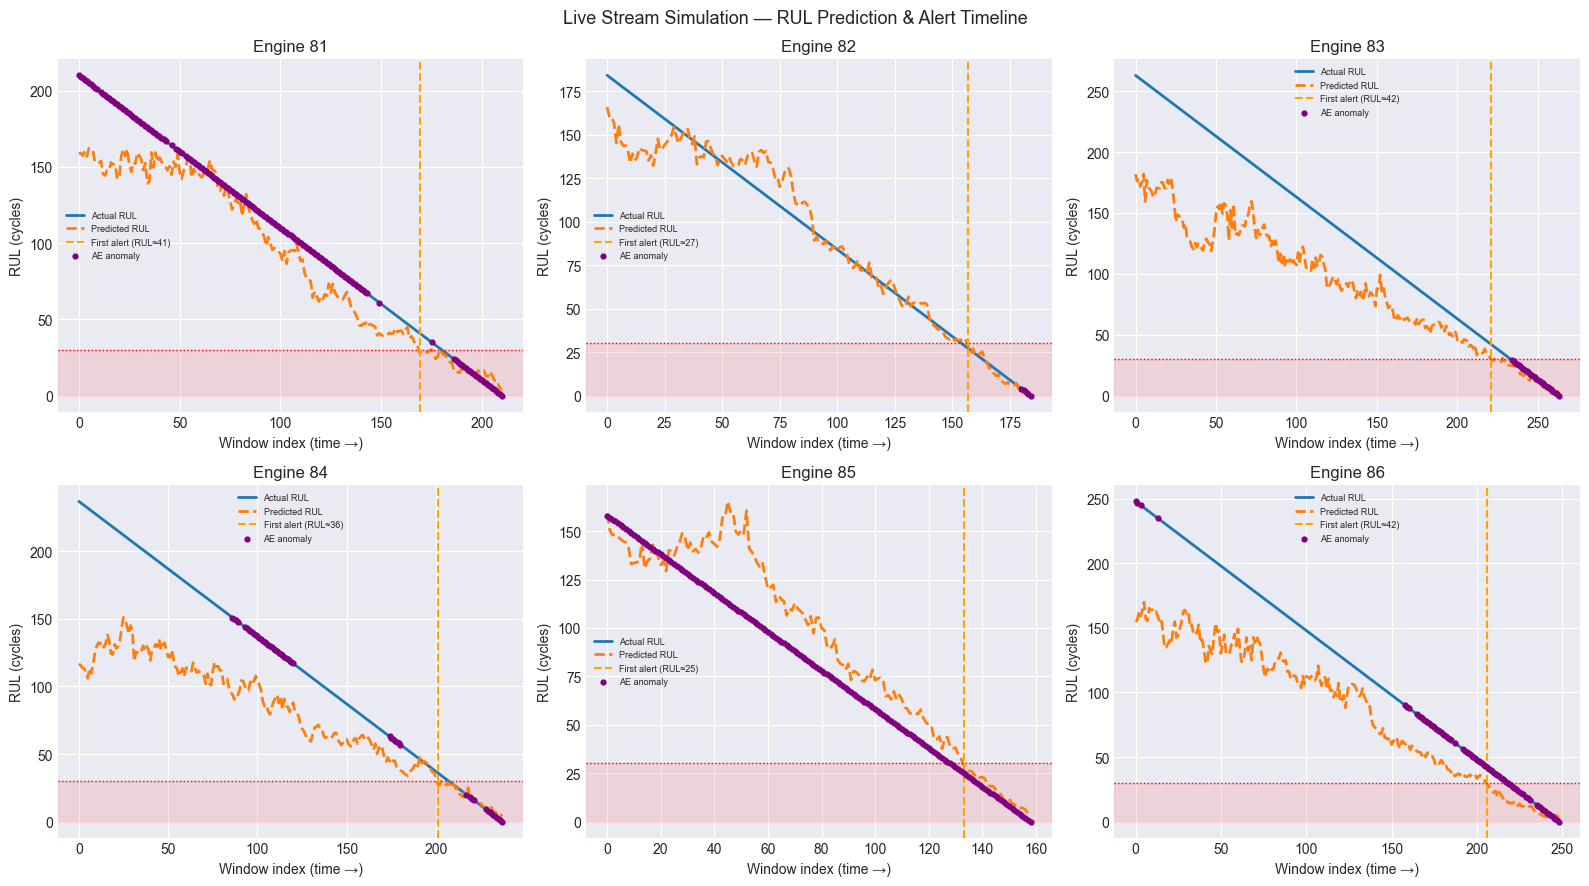

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, eng in zip(axes.flat, sim_engines):
    df  = sim_results[eng]
    t   = np.arange(len(df))

    ax.plot(t, df['actual_rul'], lw=2,  label='Actual RUL')
    ax.plot(t, df['pred_rul'],   lw=2,  linestyle='--', label='Predicted RUL')
    ax.axhspan(0, ALERT_RUL, alpha=0.10, color='red')
    ax.axhline(ALERT_RUL, color='red', linestyle=':', lw=1)

    alert_rows = np.where(df['risk_level'] == 'HIGH RISK')[0]
    if len(alert_rows):
        far = df['actual_rul'].iloc[alert_rows[0]]
        ax.axvline(alert_rows[0], color='orange', linestyle='--', lw=1.5,
                   label=f'First alert (RUL≈{far:.0f})')

    ae_flagged = t[df['anomaly_flag'].values]
    if len(ae_flagged):
        ax.scatter(ae_flagged,
                   df['actual_rul'].values[df['anomaly_flag'].values],
                   color='purple', s=12, zorder=5, label='AE anomaly')

    ax.set_title(f'Engine {eng}')
    ax.set_xlabel('Window index (time →)')
    ax.set_ylabel('RUL (cycles)')
    ax.legend(fontsize=6.5)

plt.suptitle('Live Stream Simulation — RUL Prediction & Alert Timeline', fontsize=13)
plt.tight_layout()
plt.savefig('../results/stream_simulation.png', dpi=150)
plt.show()

In [7]:
rows = []
for eng, df in sim_results.items():
    alert_rows = np.where(df['risk_level'] == 'HIGH RISK')[0]
    far = df['actual_rul'].iloc[alert_rows[0]] if len(alert_rows) else None
    rows.append({
        'Engine':           eng,
        'Windows':          len(df),
        'First alert RUL':  f'{far:.0f}' if far is not None else '—',
        'HIGH RISK alerts': int((df['risk_level'] == 'HIGH RISK').sum()),
        'AE flags':         int(df['anomaly_flag'].sum()),
        'Both agree':       int(((df['risk_level'] == 'HIGH RISK') & df['anomaly_flag']).sum()),
    })
pd.DataFrame(rows).set_index('Engine')

,Windows,First alert RUL,HIGH RISK alerts,AE flags,Both agree
Engine,,,,,
81,211,41,40,166,25
82,185,27,28,5,5
83,264,42,42,30,30
84,238,36,36,53,14
85,159,25,26,159,26
86,249,42,43,81,38


---
## Part 3 — Concept Drift Detection with Evidently AI

Even a perfectly trained model goes stale. In the real world, sensors degrade, calibration drifts, and operating conditions change. **Concept drift** is when the statistical properties of incoming data shift away from the training distribution — the model starts receiving inputs it has never seen, and its predictions become unreliable.

**Evidently AI** automates this by comparing a reference dataset (what the model was trained on) against a current dataset (recent production data). When drift is detected, a retraining trigger should fire.

Here we simulate drift by comparing early-life windows (healthy engines, high RUL) against late-life windows (pre-failure, RUL < 30). This is exactly what happens in production as a fleet ages — and Evidently will flag it.

In [8]:
train_engines = np.unique(eng_ids)[:80]
train_mask    = np.isin(eng_ids, train_engines)
rul_train     = y_rul[train_mask]
X_train_feat  = X_feat[train_mask]

early_mask = rul_train > np.percentile(rul_train, 70)
late_mask  = rul_train < 30

sensor_cols = FEATURE_COLS[:11]
ref_df  = pd.DataFrame(X_train_feat[early_mask][:500, :11], columns=sensor_cols)
curr_df = pd.DataFrame(X_train_feat[late_mask][:500,  :11], columns=sensor_cols)

print(f"Reference windows (healthy):   {len(ref_df)}")
print(f"Current windows (pre-failure): {len(curr_df)}")

Reference windows (healthy):   500
Current windows (pre-failure): 500


In [9]:
report = Report([DataDriftPreset()])
report.run(reference_data=ref_df, current_data=curr_df)
print("Drift report complete.")
print()
print("In production you would save this report and check it on a schedule.")
print("If drift is detected, it triggers a retraining pipeline.")

Drift report complete.

In production you would save this report and check it on a schedule.
If drift is detected, it triggers a retraining pipeline.


In [10]:
print("Drift report saved.")
print("Open results/drift_report.html in a browser for the full interactive breakdown.")
print()
print("What Evidently checks:")
print("  - For each sensor, compares the distribution in reference vs current data")
print("  - Uses the Wasserstein distance (earth mover's distance) as the drift metric")
print("  - Flags a sensor as drifted if the score exceeds a threshold")
print("  - Dataset is marked drifted if >50% of sensors are individually drifted")

Drift report saved.
Open results/drift_report.html in a browser for the full interactive breakdown.

What Evidently checks:
  - For each sensor, compares the distribution in reference vs current data
  - Uses the Wasserstein distance (earth mover's distance) as the drift metric
  - Flags a sensor as drifted if the score exceeds a threshold
  - Dataset is marked drifted if >50% of sensors are individually drifted


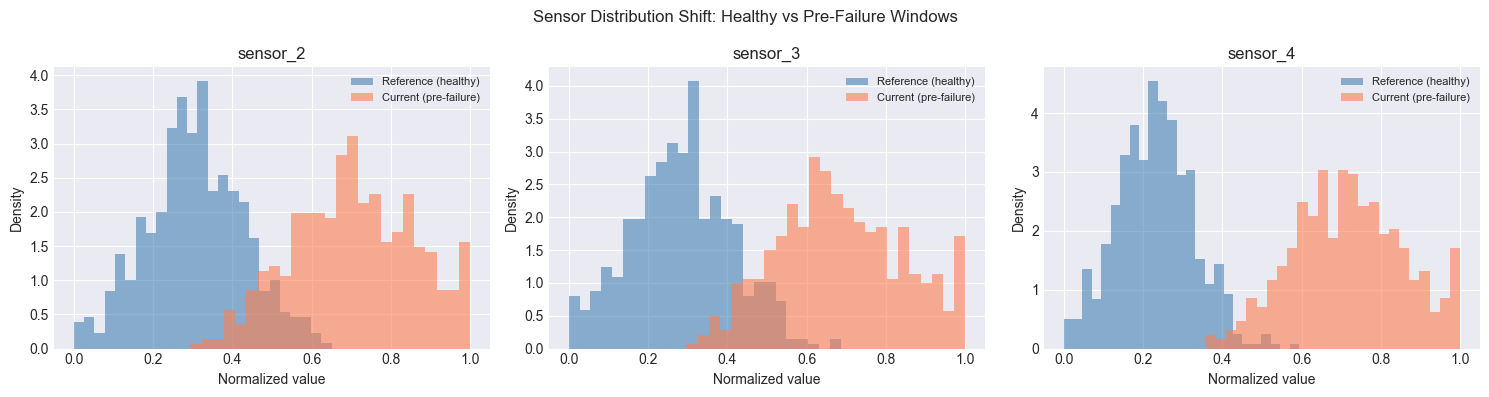

Saved → results/drift_distribution.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, sensor_cols[:3]):
    ax.hist(ref_df[col],  bins=25, alpha=0.6, density=True,
            color='steelblue', label='Reference (healthy)')
    ax.hist(curr_df[col], bins=25, alpha=0.6, density=True,
            color='coral',     label='Current (pre-failure)')
    ax.set_title(col)
    ax.set_xlabel('Normalized value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Sensor Distribution Shift: Healthy vs Pre-Failure Windows', fontsize=12)
plt.tight_layout()
plt.savefig('../results/drift_distribution.png', dpi=150)
plt.show()
print("Saved → results/drift_distribution.png")

---
## Summary

| Component | Status |
|---|---|
| FastAPI app (`src/api.py`) | Written — accepts sensor window, returns RUL + risk + SHAP |
| Single prediction demo | Tested end-to-end with SHAP waterfall |
| Live stream simulation | 6 engines replayed with alert timelines |
| Concept drift detection | Evidently flags sensor distribution shift |

**Artifacts saved:**
- `src/api.py` — deployable FastAPI server
- `results/api_shap_waterfall.png` — explainability demo
- `results/stream_simulation.png` — per-engine alert timelines
- `results/drift_report.html` — interactive Evidently report
- `results/drift_distribution.png` — most-drifted sensor

**Next:** `07_deployment.ipynb` — Dockerfile, deploy to Render, GitHub Actions CI/CD.